tuple throughput
0    1810.6
Name: throughput_txn_per_sec, dtype: float64
10         1
8       1000
6      10000
4      25000
2      50000
0     100000
Name: g_partition_covering_lock_unit_sz, dtype: int64
[1.0e-03 1.0e+00 1.0e+01 2.5e+01 5.0e+01 1.0e+02]


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


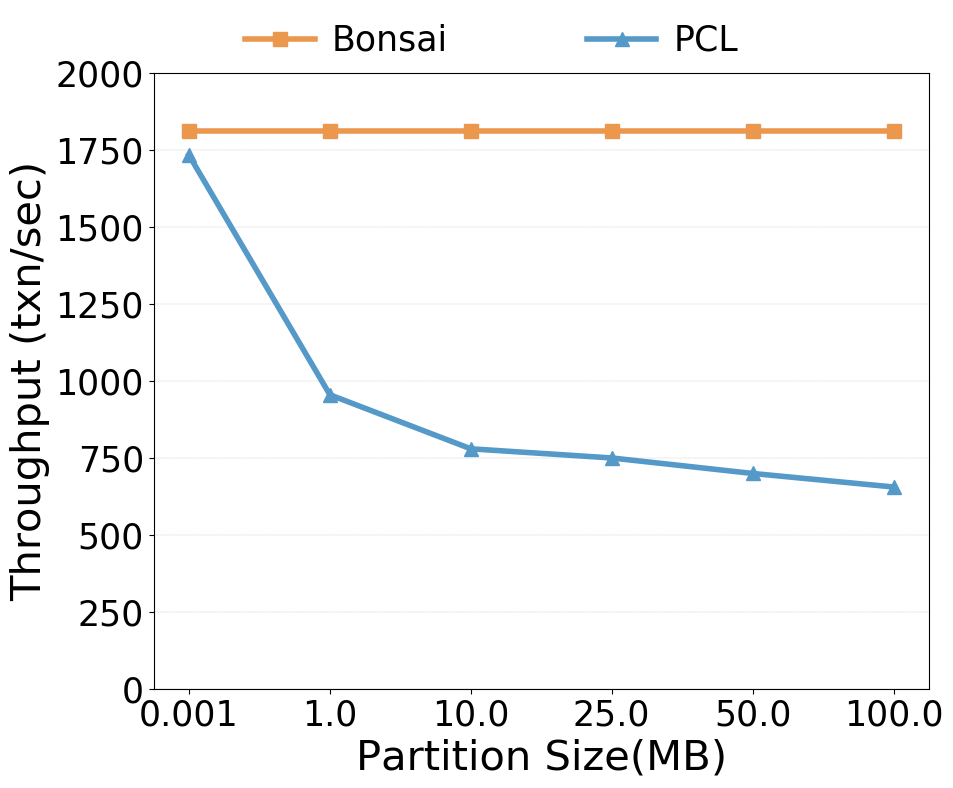

In [31]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)
txtsize=30
ticksize=25


plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
# idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../../output/"
exp_next_key = "exp_mix_bonsai_varying_psize_high_contention"
exp_partition_lock = "exp_mix_pcl_varying_psize_high_contention"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
# only get result for cache size 0.75
df_next_key = apply_mask(df_next_key, [
    ["g_total_buf_sz", ["eq", 9000000000]]
])

df_next_key = df_next_key.sort_values(by='g_partition_covering_lock_unit_sz')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = apply_mask(df_partition_lock, [
    ["g_total_buf_sz", ["eq", 9000000000]]
])


df_partition_lock = df_partition_lock.sort_values(by='g_partition_covering_lock_unit_sz')

# print(df_tuple)
fig = plt.figure(figsize=(10, 8))

# fig, ax = plt.subplots()
ax = fig.add_subplot(1, 1, 1)

print("tuple throughput")
print(df_next_key["throughput_txn_per_sec"])
single_value = df_next_key["throughput_txn_per_sec"].iloc[0]
repeat_count = len(df_partition_lock["g_partition_covering_lock_unit_sz"])
    
tuple_throughput = np.repeat(single_value, repeat_count)

ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])/1000
index = np.arange(len(ticks))
# ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])
print(df_partition_lock["g_partition_covering_lock_unit_sz"])
print(ticks)
line_width= 4
ms = 10
ax.plot(index, 
        tuple_throughput,
        color=line_colors["ORANGE"],
        marker="s", markersize=ms, linewidth=line_width, label="Bonsai")

ax.plot(index, 
        df_partition_lock["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="^", markersize=ms, linewidth=line_width, label="PCL")

ax.set_ylim(0, 2000)
#ax.set_xlim(0, 1)
# print(df_partition_lock["g_partition_covering_lock_unit_sz"]/1000)

# ax.set_xticks(ticks)
plt.xticks(index,ticks)
# ax.set_xlim([ticks.min() - 1, ticks.max() + 1])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
ax.set_xlabel("Partition Size(MB)", fontsize=txtsize)
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# ax.set_title("Throughput Varying Partition Size (buffer 0.75, 25% RW Txn ratio)")
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=2,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.9, frameon=False)

legend = plt.legend(fontsize=ticksize, bbox_to_anchor=(0.1, 1.0, 1.1, .102), loc=2,
           ncol=2,borderaxespad=0., frameon=False,columnspacing=4, handletextpad=0.5)
plt.tick_params(axis='both', labelsize=ticksize)
# for line in legend.get_lines():
#     line.set_linewidth(10)  # Set your desired linewidth
# ax.set_title("Throughput Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-psize-high-contention.pdf",bbox_inches='tight')


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


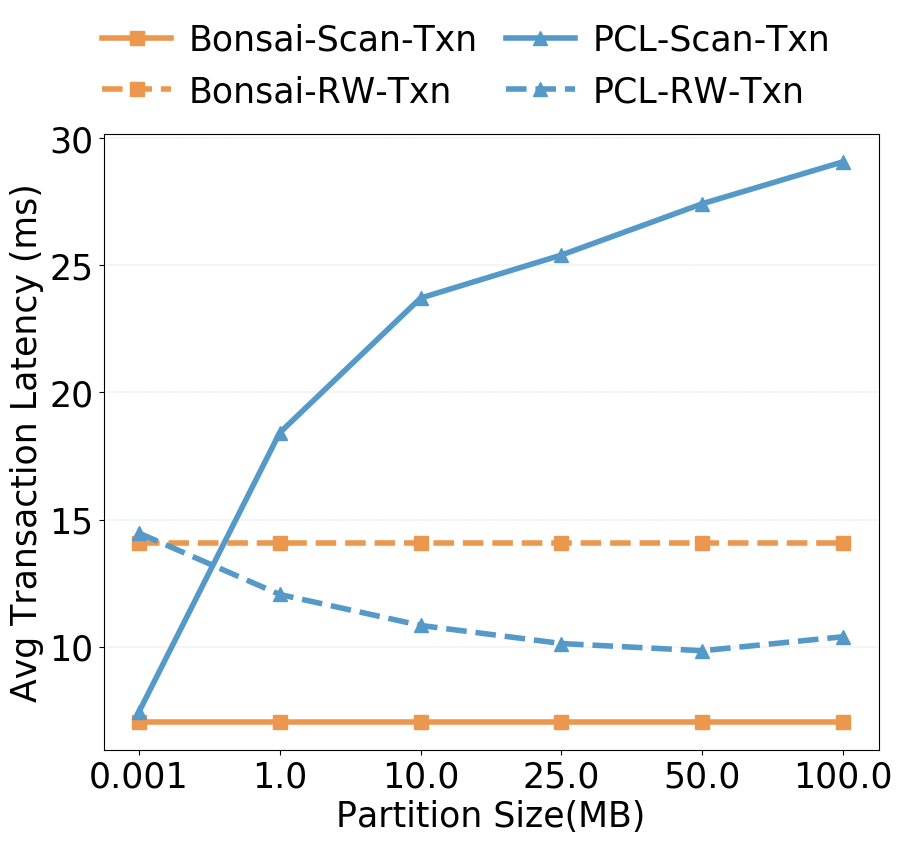

In [32]:
from matplotlib.patches import Patch
fig = plt.figure(figsize=(10, 8))
bonsai_c = "#ea801c"
# page_retain_c = "#2066a8" 
# page_evict_c = "#3594cc"

page_retain_c = "#31a354" 
page_evict_c = "#78c679"

tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1" 
bonsai_line = "s"
page_line = "^"
tt_line = "o"

ax= fig.add_subplot(1, 1, 1)
bar_width = 0.4
ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])/1000
index = np.arange(len(ticks))
repeat_count = len(df_partition_lock["g_partition_covering_lock_unit_sz"])

single_value = df_next_key["avg_sum_scan_txn_latency (us)"].iloc[0]/1000

tuple_scan_latency = np.repeat(single_value, repeat_count)

single_value = df_next_key["avg_sum_rw_txn_latency (us)"].iloc[0]/1000

tuple_rw_latency = np.repeat(single_value, repeat_count)

line_width = 4
ms = 10
ax.plot(index, 
        tuple_scan_latency,
        color=line_colors["ORANGE"],linewidth=line_width,
        marker="s", markersize= ms,  label="Bonsai-Scan-Txn")
ax.plot(index, 
        # df_tuple["txn_latency_perc99_us"]/1000,
        tuple_rw_latency,
        color=line_colors["ORANGE"],linewidth=line_width,
        marker="s", markersize= ms, label="Bonsai-RW-Txn", linestyle='dashed')


ax.plot(index, 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],  linewidth=line_width,
        marker="^", markersize= ms, label="PCL-Scan-Txn")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(index, 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["BLUE"], linewidth=line_width,
        marker="^", markersize= ms, label="PCL-RW-Txn", linestyle='dashed')
ax.tick_params(axis='both', labelsize=ticksize)
# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
# ax.set_xticks(df_next_key["zipf_theta_"])
plt.xticks(index,ticks)
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
# ax.legend(loc=location, frameon=False)
legend = ax.legend(fontsize=ticksize, bbox_to_anchor=(-0.02, 1.1, 1.1, .102), loc=2,
           ncol=2,borderaxespad=0., frameon=False,columnspacing=0.8, handletextpad=0.5)
ax.set_ylabel("Avg Transaction Latency (ms)", fontsize=ticksize)
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
ax.set_xlabel("Partition Size(MB)", fontsize=ticksize)
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-psize-high-contention-latency.pdf",bbox_inches='tight')

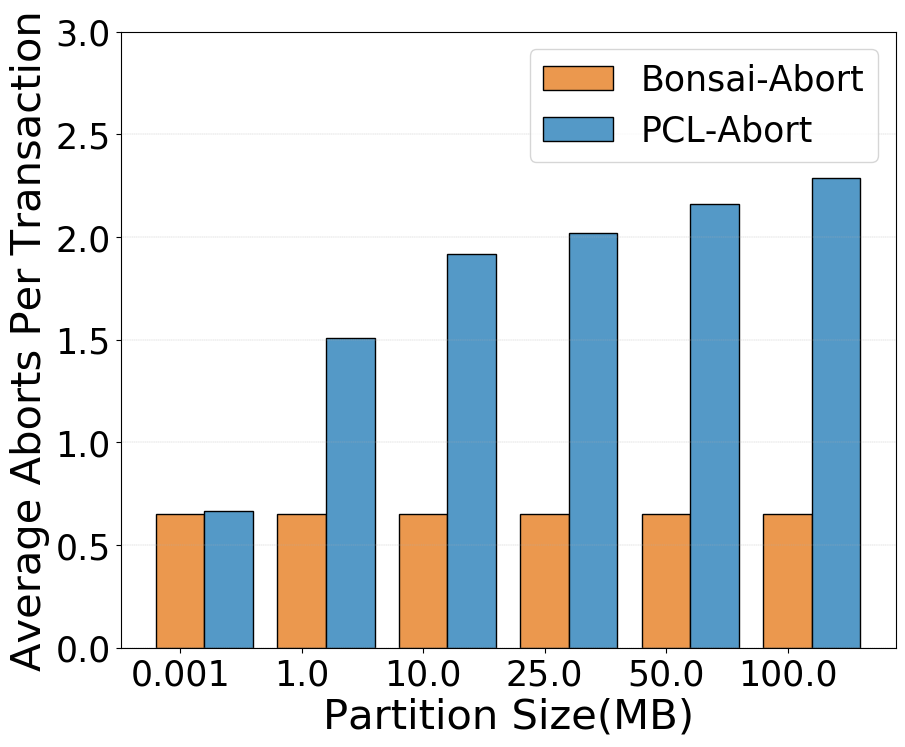

In [39]:
from matplotlib.patches import Patch
fig = plt.figure(figsize=(10, 8))
bonsai_c = "#ea801c"
# page_retain_c = "#2066a8" 
# page_evict_c = "#3594cc"

page_retain_c = "#31a354" 
page_evict_c = "#78c679"

tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1" 
bonsai_line = "s"
page_line = "^"
tt_line = "o"

ax1 = fig.add_subplot(1, 1, 1)
bar_width = 0.4
ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])/1000
index = np.arange(len(ticks))


ax1.bar(index + 2 * bar_width, 
        df_next_key["abort_cnt_"]/df_next_key["txn_cnt_"] , width=bar_width,edgecolor='black',  
        color=line_colors["ORANGE"],
        label="Bonsai-Abort")


# ax1.bar(index + 2 * bar_width, 
#           df_next_key["rw_abort_cnt_"]/df_next_key["txn_cnt_"], bottom=df_next_key["scan_abort_cnt_"]/df_next_key["txn_cnt_"], width=bar_width, edgecolor='black', hatch='\\',
#         color=line_colors["ORANGE"],
#         label="Bonsai-Write-Abort")

ax1.bar(index + 3 * bar_width, 
        df_partition_lock["abort_cnt_"]/df_partition_lock["txn_cnt_"] , width=bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="PCL-Abort")


# ax1.bar(index + 3* bar_width, 
#           df_partition_lock["rw_abort_cnt_"]/df_partition_lock["txn_cnt_"], bottom=df_partition_lock["scan_abort_cnt_"]/df_partition_lock["txn_cnt_"], width=bar_width, edgecolor='black',  hatch='\\',
#         color=line_colors["BLUE"],
#         label="PCL-Write-Abort")

plt.xticks(index + bar_width * (5 - 1) / 2,ticks)
# location = "upper left"
location = "best"
ax1.legend(loc=location, fontsize=ticksize)
ax1.set_ylabel("Average Aborts Per Transaction", fontsize=txtsize)
ax1.set_xlabel("Partition Size(MB)", fontsize=txtsize)
ax1.tick_params(axis='both', labelsize=ticksize)
ax1.set_ylim(0.0,3.0)

# ax1.set_xscale('log')
# ax1.set_title("Txn Abort Ratio(buffer 1.25, 25% RW Txn ratio)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


# subcategories = ['Scan-Abort', 'Write-Abort']  # Stacks within each bar
# bar_labels = [ 'PCL', 'Bonsai']  # Bars within each group


# # Colors for the bars (categories)
# colors = [line_colors["BLUE"], line_colors["ORANGE"]]

# # Hatches for the subcategories
# hatches = ['//', '\\']

# # Create custom patches for the subcategories
# hatch_patches = [Patch(facecolor='white', edgecolor='black', hatch=h, label=sc)
#                  for h, sc in zip(hatches, subcategories)]

# # Create custom patches for the categories
# color_patches = [Patch(facecolor=c, edgecolor='black', label=bl)
#                  for c, bl in zip(colors, bar_labels)]
# # ax1.set_ylim(0, 400)

# # Create legends
# subcat_legend = plt.legend(handles=hatch_patches, loc='best')
# ax1.add_artist(subcat_legend)  # Add the first legend manually to keep it when adding the second


# plt.legend(handles=color_patches, bbox_to_anchor=(0., 0.9, 1.13, .102), loc=2,
#            ncol=2,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)

# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-analysis-latency-breakdown.pdf",bbox_inches='tight')
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-psize-high-contention-abort.pdf",bbox_inches='tight')



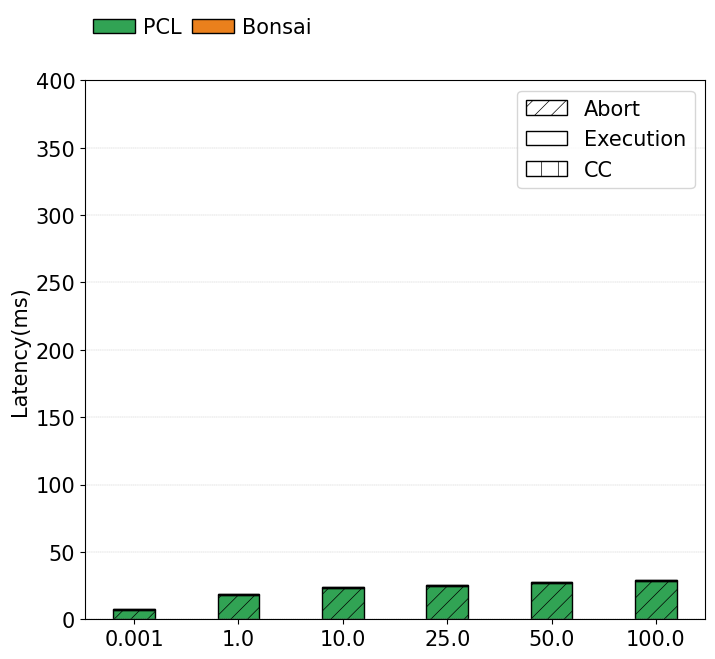

In [5]:
from matplotlib.patches import Patch
fig = plt.figure(figsize=(8, 7))
bonsai_c = "#ea801c"
# page_retain_c = "#2066a8" 
# page_evict_c = "#3594cc"

page_retain_c = "#31a354" 
page_evict_c = "#78c679"

tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1" 
bonsai_line = "s"
page_line = "^"
tt_line = "o"

ax1 = fig.add_subplot(1, 1, 1)
ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])/1000
index = np.arange(len(ticks))

cur_label="PCL"
cur_color=page_retain_c
cur_df = df_partition_lock
abort_latency = "avg_scan_abort_time_ (us)"
sum_latency = "avg_sum_scan_txn_latency (us)"
cur_exec_time = cur_df[sum_latency] - cur_df[abort_latency] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 2

ax1.bar(index + cur_idx * bar_width, 
        cur_df[abort_latency]/1000.0 , width=bar_width,edgecolor='black', hatch='//',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df[abort_latency]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df[abort_latency], cur_exec_time)], width=bar_width, edgecolor='black', hatch='|',
        color=cur_color,
        label=cur_label+"-CC-Time")


# cur_label="Bonsai"
# cur_color=bonsai_c
# cur_df = df_next_key
# abort_latency = "avg_scan_abort_time_ (us)"
# sum_latency = "avg_sum_scan_txn_latency (us)"
# cur_exec_time = cur_df[sum_latency] - cur_df[abort_latency] - cur_df["avg_cc_time_ (us)"] 
# cur_idx = 1

# ax1.bar(index + cur_idx * bar_width, 
#         cur_df[abort_latency]/1000.0 , width=bar_width,edgecolor='black', hatch='//',
#         color=cur_color,
#         label=cur_label+"-Abort-Time")
# ax1.bar(index + cur_idx * bar_width, 
#         cur_exec_time/1000.0, bottom=cur_df[abort_latency]/1000.0, width=bar_width, edgecolor='black',
#         color=cur_color,
#         label=cur_label+"-Execution-Time")
# ax1.bar(index + cur_idx * bar_width, 
#         cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df[abort_latency], cur_exec_time)], width=bar_width, edgecolor='black', hatch='|',
#         color=cur_color,
#         label=cur_label+"-CC-Time")

ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])/1000
# plt.xticks(ticks)
plt.xticks(index + bar_width * (5 - 1) / 2,ticks)
# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Latency(ms)")
# ax1.set_xlabel("Zipf Theta")
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# ax1.set_xlabel("Buffer Ratio (%, Buffer Size/Data Size)")
ax.set_xlabel("Partition Size(MB)")

subcategories = ['Abort', 'Execution', 'CC']  # Stacks within each bar
bar_labels = [ 'PCL', 'Bonsai']  # Bars within each group


# Colors for the bars (categories)
colors = [page_retain_c, bonsai_c]

# Hatches for the subcategories
hatches = ['//', '', '|', '\\\\']

# Create custom patches for the subcategories
hatch_patches = [Patch(facecolor='white', edgecolor='black', hatch=h, label=sc)
                 for h, sc in zip(hatches, subcategories)]

# Create custom patches for the categories
color_patches = [Patch(facecolor=c, edgecolor='black', label=bl)
                 for c, bl in zip(colors, bar_labels)]
ax1.set_ylim(0, 400)

# Create legends
subcat_legend = plt.legend(handles=hatch_patches, loc='best')
ax1.add_artist(subcat_legend)  # Add the first legend manually to keep it when adding the second
plt.legend(handles=color_patches, bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)

# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-analysis-latency-breakdown.pdf",bbox_inches='tight')
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-psize-high-contention-scan-latency-breakdown.pdf",bbox_inches='tight')




8     1592.87
11    1761.60
5     1696.00
10    1709.80
2     1679.60
0     1693.13
Name: throughput_txn_per_sec, dtype: float64
tuple throughput
0    1733.53
Name: throughput_txn_per_sec, dtype: float64


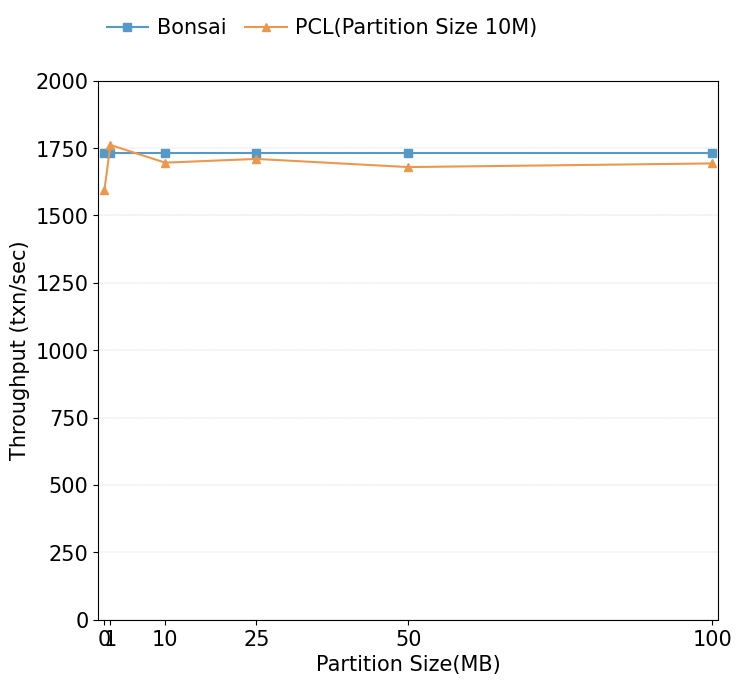

In [31]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
# idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../../output/"
exp_next_key = "exp_mix_bonsai_varying_psize_low_contention"
exp_partition_lock = "exp_mix_pcl_varying_psize_low_contention"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
# only get result for cache size 0.75
df_next_key = apply_mask(df_next_key, [
    ["g_total_buf_sz", ["eq", 9000000000]]
])

df_next_key = df_next_key.sort_values(by='g_partition_covering_lock_unit_sz')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = apply_mask(df_partition_lock, [
    ["g_total_buf_sz", ["eq", 9000000000]]
])


df_partition_lock = df_partition_lock.sort_values(by='g_partition_covering_lock_unit_sz')

print(df_partition_lock["throughput_txn_per_sec"])

# print(df_tuple)
fig = plt.figure(figsize=(8, 7))

# fig, ax = plt.subplots()
ax = fig.add_subplot(1, 1, 1)

print("tuple throughput")
print(df_next_key["throughput_txn_per_sec"]);
single_value = df_next_key["throughput_txn_per_sec"].iloc[0]
repeat_count = len(df_partition_lock["g_partition_covering_lock_unit_sz"])
    
tuple_throughput = np.repeat(single_value, repeat_count)

ticks = np.array(df_partition_lock["g_partition_covering_lock_unit_sz"])/1000

ax.plot(ticks, 
        tuple_throughput,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(ticks, 
        df_partition_lock["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="^", label="PCL(Partition Size 10M)")

# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
# print(df_partition_lock["g_partition_covering_lock_unit_sz"]/1000)

ax.set_xticks(ticks)
ax.set_xlim([ticks.min() - 1, ticks.max() + 1])
ax.set_ylim([0, 2000])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Partition Size(MB)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# ax.set_title("Throughput Varying Partition Size (buffer 0.75, 25% RW Txn ratio)")
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=2,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.9, frameon=False)
# for line in legend.get_lines():
#     line.set_linewidth(10)  # Set your desired linewidth
# ax.set_title("Throughput Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev2-scan-psize-low-contention.pdf",bbox_inches='tight')


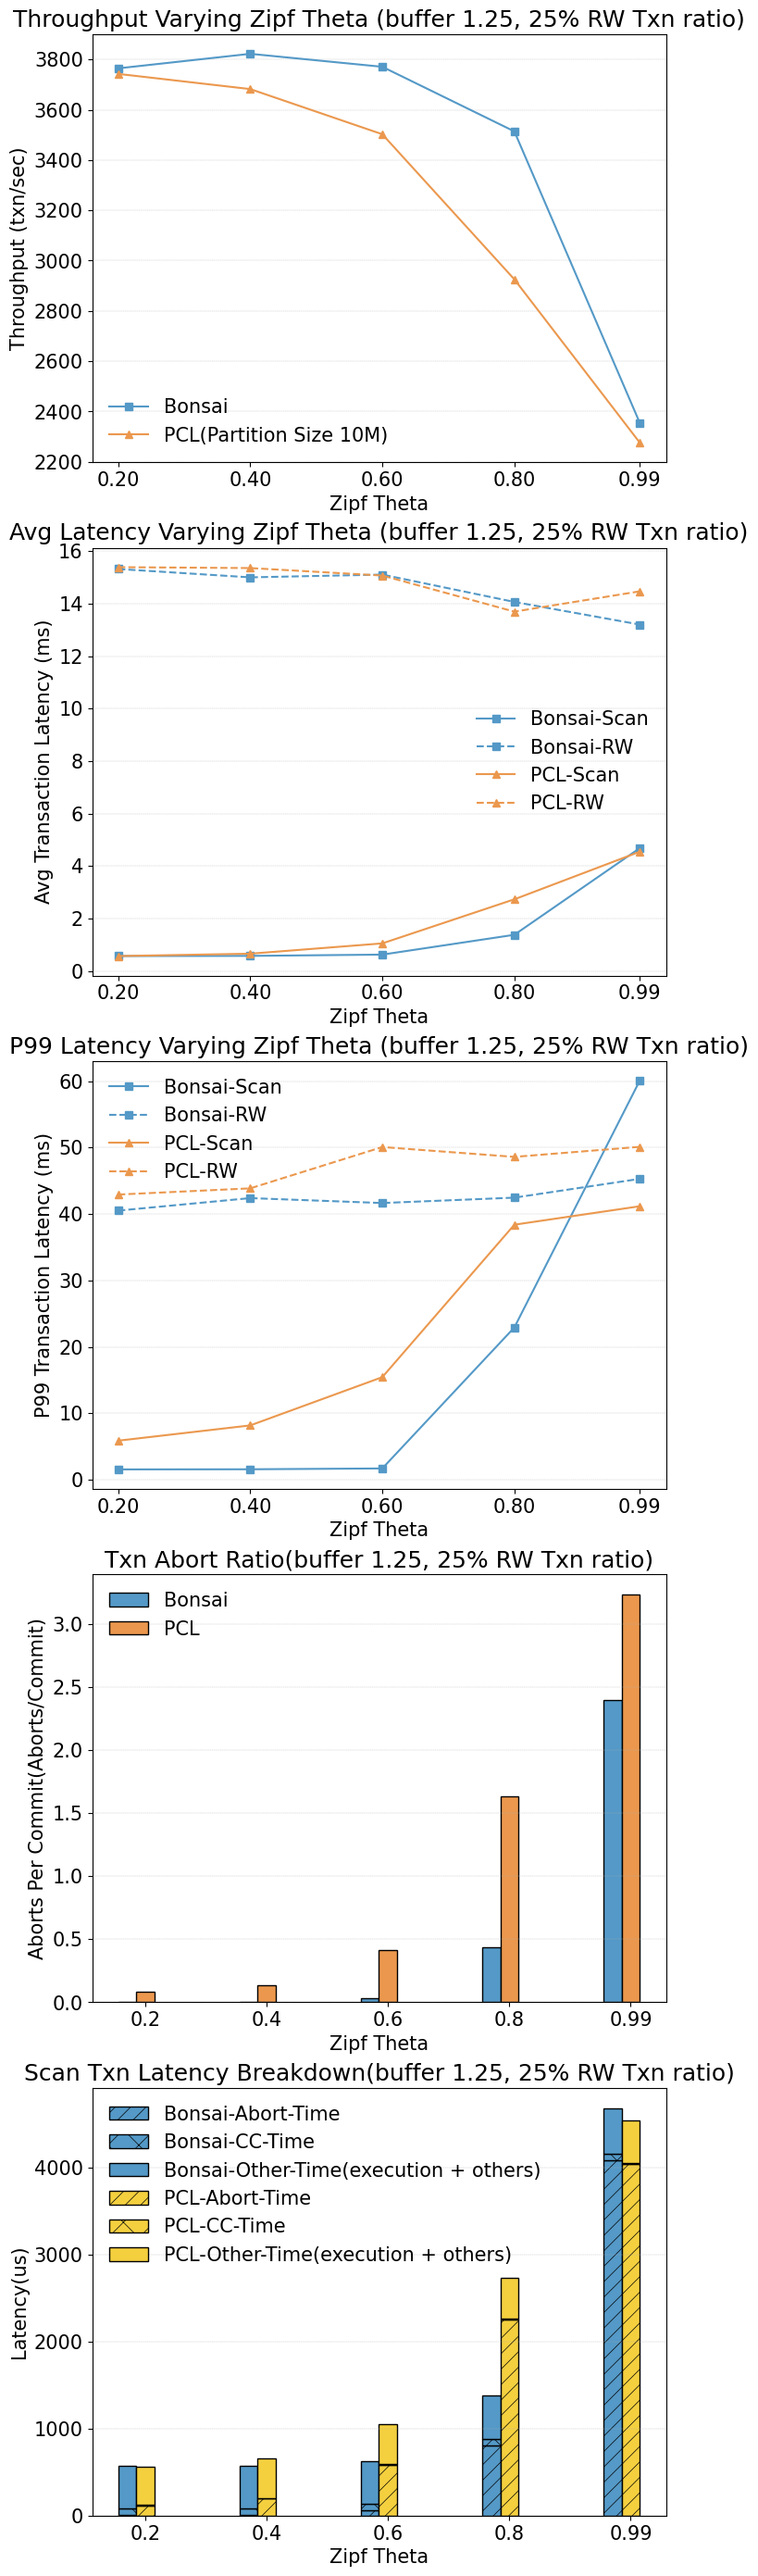

In [28]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
# idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../../output/"
exp_next_key = "exp_mix_scan_10g_bonsai_test_demo_zipf"
exp_partition_lock = "exp_mix_scan_partition_lock_Psize_test_demo_zipf"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
df_next_key = df_next_key.sort_values(by='zipf_theta_')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = df_partition_lock.sort_values(by='zipf_theta_')

# print(df_tuple)
fig = plt.figure(figsize=(8, 42))

# fig, ax = plt.subplots()
ax = fig.add_subplot(6, 1, 1)


ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="^", label="PCL(Partition Size 10M)")

# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Zipf Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Zipf Theta (buffer 1.25, 25% RW Txn ratio)")



ax = fig.add_subplot(6, 1, 2)


ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")
ax.plot(df_next_key["zipf_theta_"], 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_next_key["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW", linestyle='dashed')


ax.plot(df_partition_lock["zipf_theta_"], 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["zipf_theta_"], 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
ax.set_xlabel("Zipf Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying Zipf Theta (buffer 1.25, 25% RW Txn ratio)")


ax = fig.add_subplot(6, 1, 3)


# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")

ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["scan_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")

ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["rw_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW",linestyle='dashed')



ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["scan_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["rw_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Zipf Theta")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("P99 Latency Varying Zipf Theta (buffer 1.25, 25% RW Txn ratio)")


index = np.arange(len(df_next_key["zipf_theta_"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 4)


ax1.bar(index + 1 * bar_width, 
        df_next_key["abort_cnt_"]/df_next_key["txn_cnt_"] , width=bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_partition_lock["abort_cnt_"]/df_partition_lock["txn_cnt_"], width=bar_width, edgecolor='black',
        color=line_colors["ORANGE"],
        label="PCL")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Aborts Per Commit(Aborts/Commit)")
ax1.set_xlabel("Zipf Theta")
# ax1.set_xscale('log')
ax1.set_title("Txn Abort Ratio(buffer 1.25, 25% RW Txn ratio)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 5)

ax1.bar(index + 1 * bar_width, 
        df_next_key["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
        color=line_colors["BLUE"],
        label="Bonsai-Abort-Time")
ax1.bar(index + 1 * bar_width, 
        df_next_key["avg_cc_time_ (us)"] , bottom=df_next_key["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
        color=line_colors["BLUE"],
        label="Bonsai-CC-Time")
ax1.bar(index + 1 * bar_width, 
        df_next_key["avg_sum_scan_txn_latency (us)"] - df_next_key["avg_scan_abort_time_ (us)"] - df_next_key["avg_cc_time_ (us)"], bottom=[i+j for i, j in zip(df_next_key["avg_scan_abort_time_ (us)"], df_next_key["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai-Other-Time(execution + others)")


ax1.bar(index + 2 * bar_width, 
        df_partition_lock["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
        color=line_colors["YELLOW"],
        label="PCL-Abort-Time")
ax1.bar(index + 2 * bar_width, 
        df_partition_lock["avg_cc_time_ (us)"] , bottom=df_partition_lock["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
        color=line_colors["YELLOW"],
        label="PCL-CC-Time")
ax1.bar(index + 2 * bar_width, 
        df_partition_lock["avg_sum_scan_txn_latency (us)"] - df_partition_lock["avg_scan_abort_time_ (us)"] - df_partition_lock["avg_cc_time_ (us)"], bottom=[i+j for i, j in zip(df_partition_lock["avg_scan_abort_time_ (us)"], df_partition_lock["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black',
        color=line_colors["YELLOW"],
        label="PCL-Other-Time(execution + others)")

plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Latency(us)")
ax1.set_xlabel("Zipf Theta")
# ax1.set_xscale('log')
ax1.set_title("Scan Txn Latency Breakdown(buffer 1.25, 25% RW Txn ratio)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


# ax1 = fig.add_subplot(6, 1, 6)


# ax1.bar(index + 1 * bar_width, 
#         df_next_key["rw_abort_cnt_"]/df_next_key["rw_txn_cnt_"] , bar_width,edgecolor='black',
#         color=line_colors["BLUE"],
#         label="Bonsai")

# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["rw_abort_cnt_"]/df_partition_lock["rw_txn_cnt_"], bar_width, edgecolor='black',
#         color=line_colors["ORANGE"],
#         label="PCL")

# # plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
# plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# # location = "upper left"
# location = "best"
# ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Aborts Per Commit(Aborts/Commit)")
# ax1.set_xlabel("Zipf Theta")
# # ax1.set_xscale('log')
# ax1.set_title("RW Txn Abort Ratio(theta 0.9, writeheavy)")
# #ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
# ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

